In [52]:
import os
import pandas as pd
import ROOT
import pickle
import csv
import uproot
import numpy as np
import mplhep as hep
import awkward as ak
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy.optimize import curve_fit
from array import array
from tqdm import trange, tqdm
import random
import time 
import hist
from uncertainties import unumpy as unp
from IPython.display import display, Image

In [2]:
def normalize_histogram_with_uncertainty(histogram, input_format=None, output_format=None, flow=False):
    """
    Normalize a histogram with uncertainty propagation and support for uproot, ROOT, and hist.Hist formats.

    Args:
        histogram: Input histogram (uproot, ROOT, or hist.Hist).
        input_format (str): Format of the input histogram ("uproot", "ROOT", or "hist.Hist").
        output_format (str): Desired format of the output histogram ("uproot", "ROOT", or "hist.Hist").
        flow (bool): Whether to include underflow and overflow bins in normalization.

    Returns:
        Normalized histogram in the specified output format.
    """
    # Detect input format if not specified
    if input_format is None:
        if isinstance(histogram, hist.Hist):
            input_format = "hist"
        elif isinstance(histogram, ROOT.TH1):
            input_format = "ROOT"
        elif hasattr(histogram, "values") and hasattr(histogram, "axes"):
            input_format = "uproot"
        else:
            raise ValueError("Unable to detect input histogram format. Specify input_format.")

    # Extract values, variances, and edges based on input format
    if input_format == "hist":
        values = histogram.values(flow=flow)
        variances = histogram.variances(flow=flow)
        edges = histogram.axes[0].edges
        hist_name = "normalized by bin width"
    elif input_format == "ROOT":
        nbins = histogram.GetNbinsX()
        values = np.array([histogram.GetBinContent(i + 1) for i in range(nbins)])
        variances = np.array([histogram.GetBinError(i + 1)**2 for i in range(nbins)])
        edges = np.array([histogram.GetBinLowEdge(i + 1) for i in range(nbins + 1)])
        hist_name = histogram.GetName()
    elif input_format == "uproot":
        values = histogram.values()
        variances = histogram.variances()
        edges = histogram.axes[0].edges()
        hist_name = histogram.to_hist().name
    else:
        raise ValueError("Unsupported input_format. Use 'uproot', 'ROOT', or 'hist.Hist'.")

    #print(edges)

    # Handle cases with no entries
    total_value = np.sum(values)
    if total_value == 0:
        return histogram  # Return as-is if total is zero

    # Create array with uncertainties using unumpy
    values_with_uncert = unp.uarray(values, np.sqrt(variances))

    # Normalize the values with uncertainty propagation
    normalized_values = values_with_uncert / total_value

    # Determine output format if not provided
    if output_format is None:
        output_format = input_format

    # Generate the normalized histogram based on requested output format
    if output_format == "hist":
        normalized_hist = hist.Hist(
            histogram.axes[0],
            name=hist_name, 
            storage=hist.storage.Weight()
        )
        normalized_hist[...] = (unp.nominal_values(normalized_values),
                                unp.std_devs(normalized_values)**2)
        return normalized_hist

    elif output_format == "ROOT":
        h_density = ROOT.TH1D(hist_name, hist_name, len(values), edges[0], edges[-1])
        for i in range(len(values)):
            h_density.SetBinContent(i + 1, unp.nominal_values(normalized_values)[i])
            h_density.SetBinError(i + 1, unp.std_devs(normalized_values)[i])
        return h_density

    elif output_format == "uproot":
        h_density = hist.Hist.new.Reg(len(values), edges[0], edges[-1], name=hist_name).Double()
        h_density.view(flow=False)[...] = unp.nominal_values(normalized_values)
        h_density.variances(flow=False)[...] = unp.std_devs(normalized_values)**2
        return h_density

    else:
        raise ValueError("Unsupported output_format. Use 'uproot', 'ROOT', or 'hist.Hist'.")

# Example usage
# Assuming `h` is a histogram in one of the supported formats
# normalized_h = normalize_histogram_with_uncertainty(h, input_format="ROOT", output_format="hist.Hist")


In [69]:
merged_hists['gen_b1j'].label

'gen_b1j'

In [178]:
op_values = ['0', '2', '-2']

for value in op_values:
    
    path = f"/depot/cms/top/he614/notebooks/EFT_FullRun2/histogram_output_2016*VFP_partonEFT*{value}*/Nominal/*plustau*"
    plustau_paths = !realpath {path}
    from collections import defaultdict
    # Dictionary to hold merged histograms per variable
    merged_hists = defaultdict(lambda: None)
    
    for path in plustau_paths:
        with open(path, "rb") as f:
            hist_dict = pickle.load(f)  # a dict of {var_name: hist.Hist}
    
            for var, h in hist_dict.items():
                if merged_hists[var] is None:
                    merged_hists[var] = h.copy()
                else:
                    merged_hists[var] += h
    
    xy_labels = []
    
    # Ensure consistent order of keys (e.g., sort alphabetically or by a defined order)
    var_names = sorted(merged_hists.keys())
    
    # Assuming 6 bins per variable
    for var in var_names:
        for i in range(6):
            label = f"{var}, bin {i}"
            xy_labels.append(label)

    # Extract values and variances from all histograms
    flattened = []
    
    for var_name, h in merged_hists.items():
        values = h.values()
        variances = h.variances()
        edges = h.axes[0].edges
        bin_widths = np.diff(edges)

        assert values.shape == variances.shape == bin_widths.shape, f"Shape mismatch in {var_name}"

        uvals = unp.uarray(values, np.sqrt(variances))
        uvals_density = uvals / bin_widths  # Convert to density

        # Normalize per variable (manually sum uarray)
        total = sum(uvals_density)
        if total.n != 0:
            uvals_normed = uvals_density / total
        else:
            uvals_normed = uvals_density

        flattened.append((
            unp.nominal_values(uvals_normed).flatten(),
            unp.std_devs(uvals_normed).flatten()**2
        ))
    
    # Concatenate into a single array
    all_values = np.concatenate([vals for vals, _ in flattened])
    all_variances = np.concatenate([vars for _, vars in flattened])
    
    # Create a 1D histogram with unit-width bins
    n_bins = len(all_values)
    bin_edges = np.arange(n_bins + 1)
    
    big_hist = hist.Hist(
        hist.axis.Variable(bin_edges, name="observable"),
        storage=hist.storage.Weight()
    )
    
    # Fill histogram
    values_with_variances = np.array(
        [(val, var) for val, var in zip(all_values, all_variances)],
        dtype=[("value", "f8"), ("variance", "f8")]
    )
    big_hist[...] = values_with_variances
    
    # Save to ROOT
    with uproot.recreate(f"concatenated_histograms_ctg{value}.root") as fout:
        fout["diff_cross_section"] = big_hist
    
    print(f"Saved concatenated histogram to: concatenated_histograms_ctg{value}.root")

xy_labels = []

# Ensure consistent order of keys (e.g., sort alphabetically or by a defined order)
var_names = merged_hists.keys()

# Assuming 6 bins per variable
for var in var_names:
    for i in range(6):
        label = f"{var}, bin {i}"
        xy_labels.append(label.replace('gen_','').replace(', bin',''))

xy_labels_reduced = [label for i, label in enumerate(xy_labels) if i % 6 != 0]

print(len(xy_labels))
print(len(xy_labels_reduced))

Saved concatenated histogram to: concatenated_histograms_ctg0.root
Saved concatenated histogram to: concatenated_histograms_ctg2.root
Saved concatenated histogram to: concatenated_histograms_ctg-2.root
228
190


In [84]:
merged_hists.keys()

dict_keys(['gen_b1k', 'gen_b2k', 'gen_b1r', 'gen_b2r', 'gen_b1n', 'gen_b2n', 'gen_b1j', 'gen_b2j', 'gen_b1q', 'gen_b2q', 'gen_c_kk', 'gen_c_rr', 'gen_c_nn', 'gen_c_Prk', 'gen_c_Mrk', 'gen_c_Pnr', 'gen_c_Mnr', 'gen_c_Pnk', 'gen_c_Mnk', 'gen_c_kj', 'gen_c_rq', 'gen_c_han', 'gen_c_tra', 'gen_c_sca', 'gen_c_Prj', 'gen_c_Mrj', 'gen_c_kjL', 'gen_c_rqL', 'gen_c_rkP', 'gen_c_rkM', 'gen_c_nrP', 'gen_c_nrM', 'gen_c_nkP', 'gen_c_nkM', 'gen_ll_cHel', 'gen_ll_cLab', 'gen_llbar_delta_phi', 'gen_llbar_delta_eta'])

In [85]:
hist_stat['stat_1D_variables;1']['CovMatrix_Norm'].array()

<Array [[4.09e-05, -1.55e-05, ..., -1.34e-06], ...] type='228 * 228 * float64'>

# Prepare SM 1D concatenated histogram √

In [172]:
hist_stat = uproot.open('/depot/cms/top/dawoodo/fullRun2_UL_September2024_unfolding/CMSSW_10_6_30/src/TopAnalysis/Configuration/analysis/diLeptonic/stat_gigantic_matrix_2016.root')
hist_syst = uproot.open('/depot/cms/top/dawoodo/fullRun2_UL_September2024_unfolding/CMSSW_10_6_30/src/TopAnalysis/Configuration/analysis/diLeptonic/syst_gigantic_matrix_2016.root')

# Load arrays from awkward-based ROOT structure
central_values = hist_syst['syst_1D_variables']['hnom_AllVar_Norm'].array()
stat_cov = hist_stat['stat_1D_variables']['CovMatrix_Norm'].array()
syst_cov = hist_syst['syst_1D_variables']['CovMatrix_Norm'].array()

# Extract uncertainties from diagonals
stat_uncert = np.sqrt(np.diag(stat_cov))
syst_uncert = np.sqrt(np.diag(syst_cov))

# Total uncertainty in quadrature
total_uncert = np.sqrt(stat_uncert**2 + syst_uncert**2)

# Define unit-width bin edges: [0, 1, 2, ..., N]
n_bins = len(central_values)
bin_edges = np.arange(n_bins + 1)  # e.g., if 5 bins → [0, 1, 2, 3, 4, 5]

# Create histogram with unit-width bins
histogram = hist.Hist(
    hist.axis.Variable(bin_edges, name="observable"),
    storage=hist.storage.Weight()
)

# Fill values and uncertainties (variances)
values_with_variances = np.array(
    [(val, err**2) for val, err in zip(central_values, total_uncert)],
    dtype=[("value", "f8"), ("variance", "f8")]
)
histogram[...] = values_with_variances

# Save to ROOT
out_root = "concatenated_histograms.root"
with uproot.recreate(out_root) as fout:
    fout["diff_cross_section"] = histogram  # Or use your normalize wrapper

print(f"Saved histogram to: {out_root}")

Saved histogram to: concatenated_histograms.root


/tmp/ipykernel_70440/684602729.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar


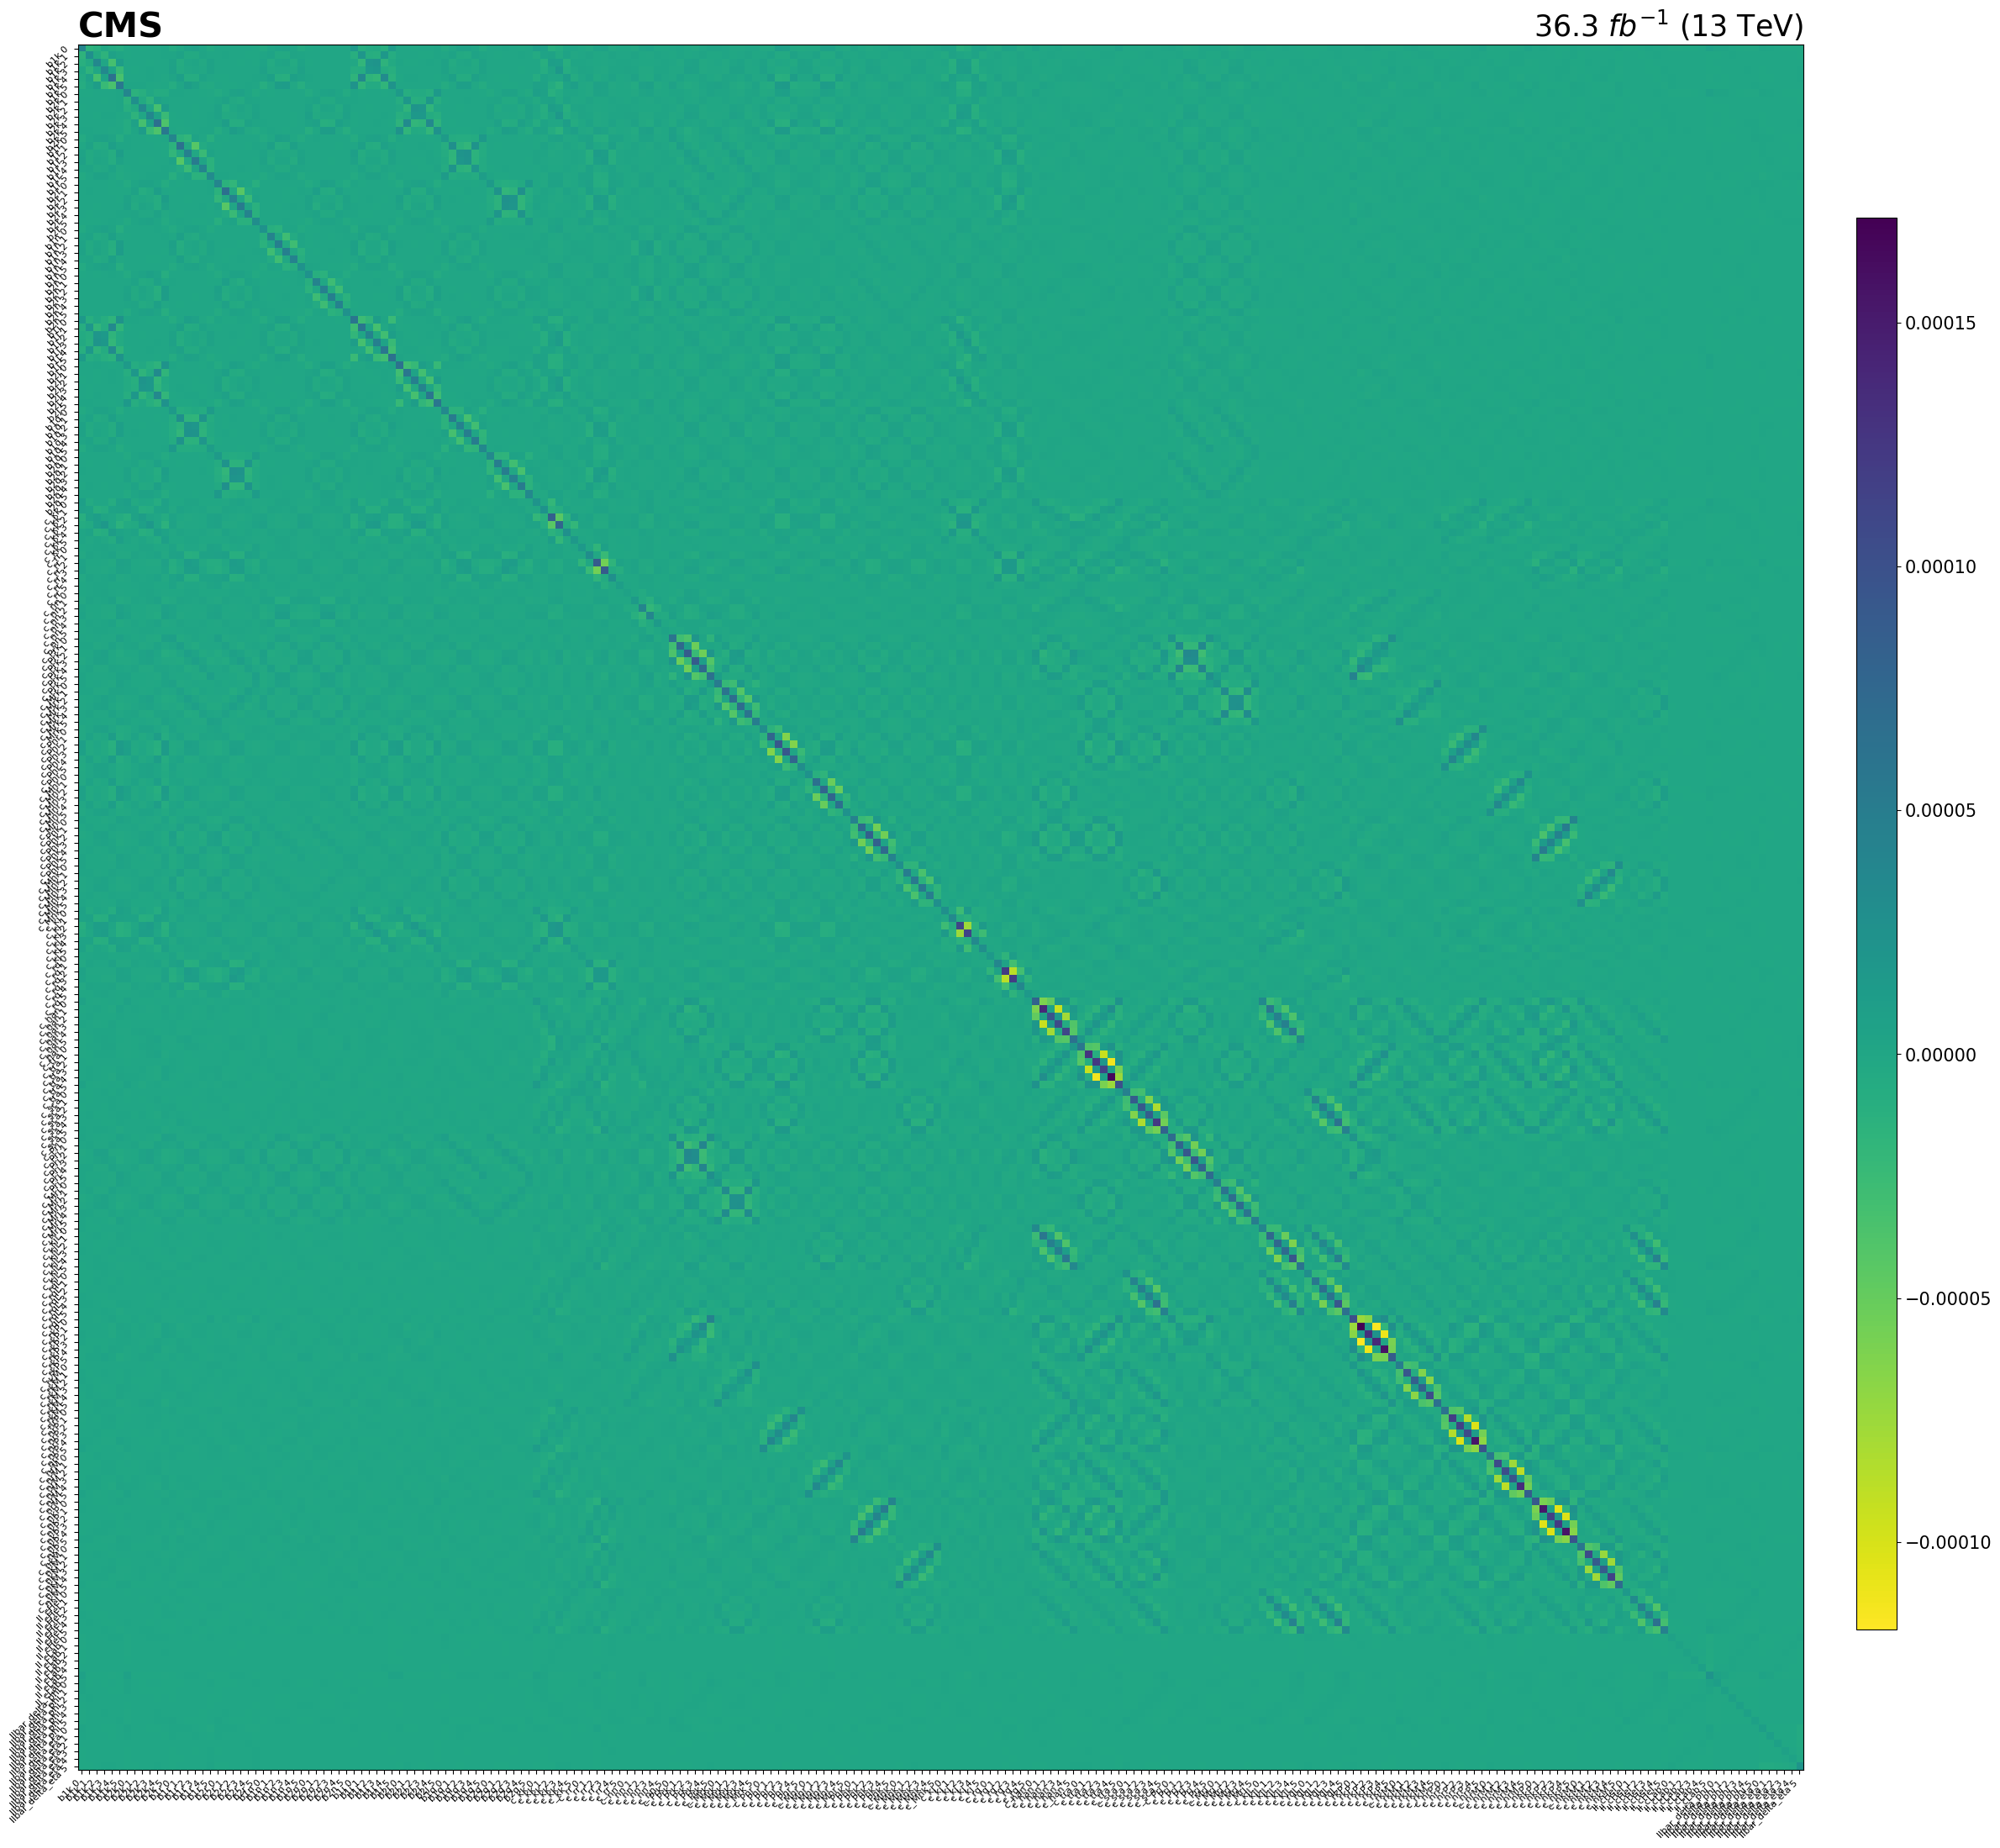

In [127]:
stat_cov_matrix = [] 
stat_cov_matrix = hist_stat["stat_1D_variables;1"]["CovMatrix_Norm"].array()

# Flip the matrix vertically
#stat_cov_matrix = np.flipud(stat_cov_matrix)

# Shape info
n_bins = len(stat_cov_matrix)

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(24, 24))

im = axs.imshow(stat_cov_matrix, cmap='viridis_r')

axs.set_title('CMS', fontsize=30, fontweight='bold', loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_xticks(np.arange(n_bins))
axs.set_xticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

axs.set_yticks(np.arange(n_bins))
axs.set_yticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=15)

axs.set_ylim(n_bins - 0.5, -0.5)  # to keep y-axis in correct order

# Optional: save to PDF
plt.savefig('stat_matrix_from_root.pdf')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar
plt.show()

/tmp/ipykernel_70440/4047076279.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar


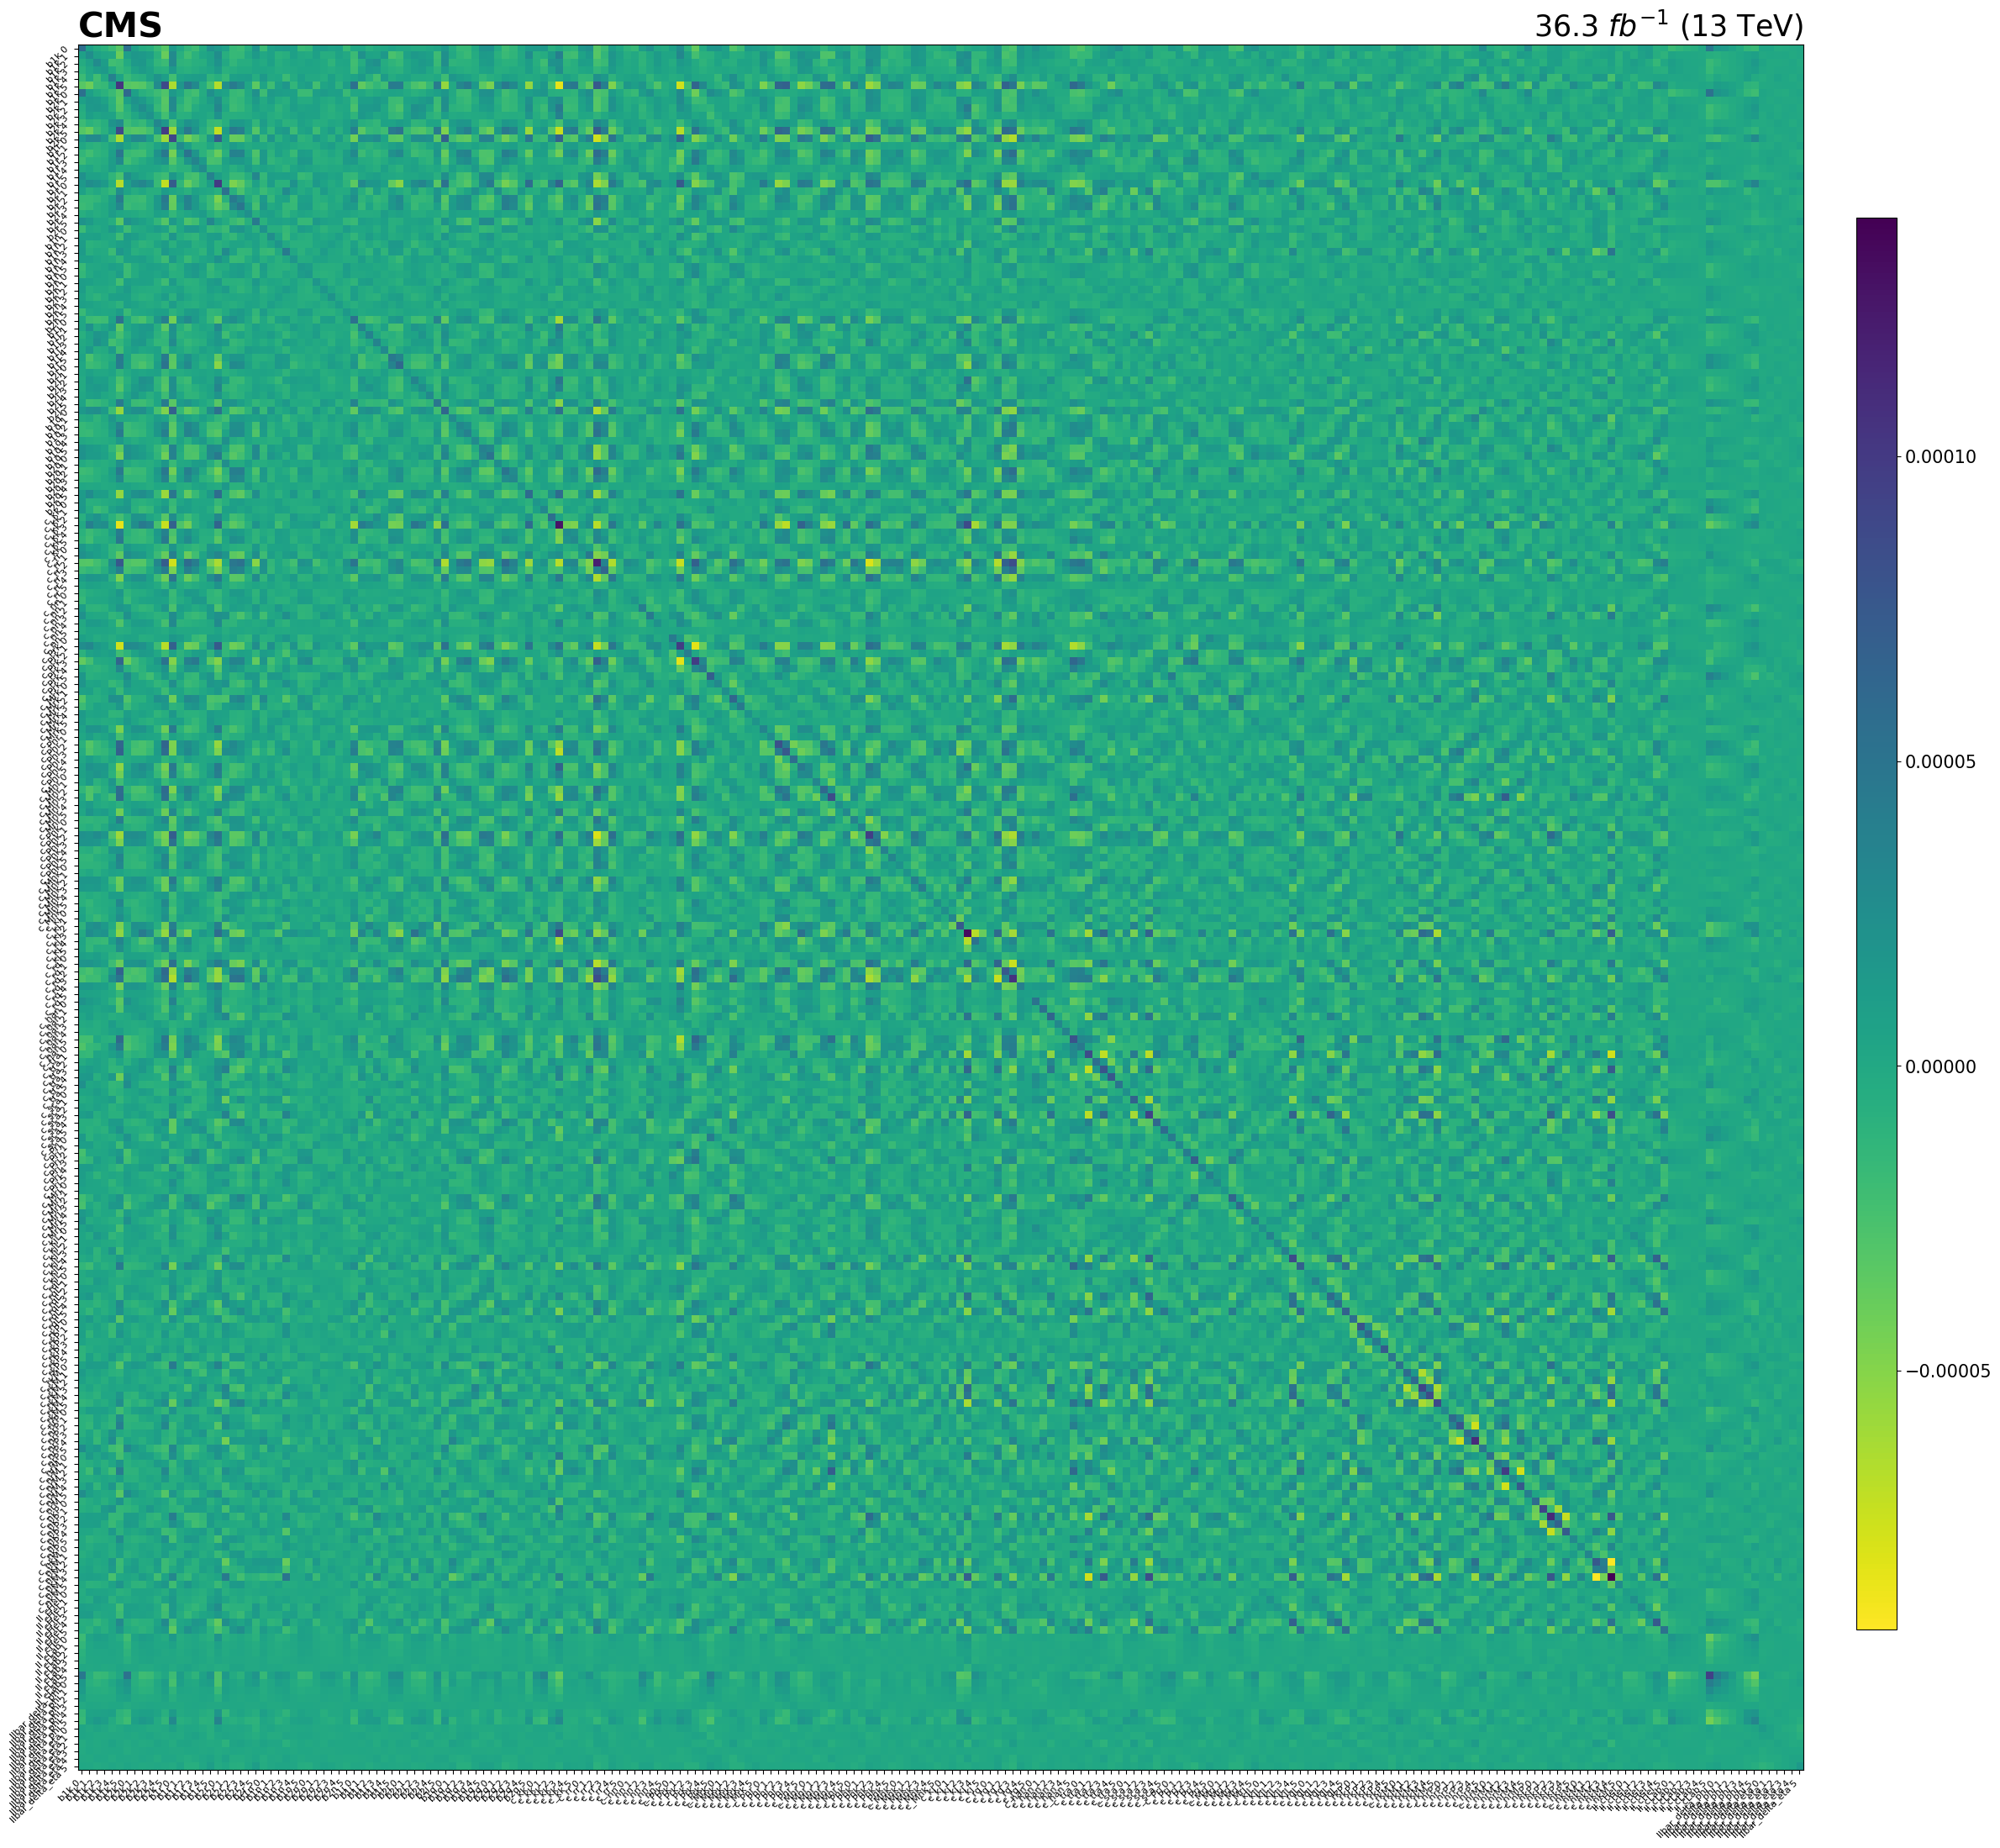

In [128]:
syst_cov_matrix = [] 
syst_cov_matrix = hist_syst["syst_1D_variables;1"]["CovMatrix_Norm"].array()

# Flip the matrix vertically
#syst_cov_matrix = np.flipud(syst_cov_matrix)

# Shape info
n_bins = len(syst_cov_matrix)

# Plotting
fig, axs = plt.subplots(1, 1, figsize=(24, 24))

im = axs.imshow(syst_cov_matrix, cmap='viridis_r')

axs.set_title('CMS', fontsize=30, fontweight='bold', loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_xticks(np.arange(n_bins))
axs.set_xticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

axs.set_yticks(np.arange(n_bins))
axs.set_yticklabels(xy_labels, rotation=45, ha='right', fontsize=8)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=15)

axs.set_ylim(n_bins - 0.5, -0.5)  # to keep y-axis in correct order

# Optional: save to PDF
plt.savefig('syst_matrix_from_root.pdf')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # adjust for colorbar
plt.show()

finalcov = np.add( stat_cov_matrix, syst_cov_matrix )

bins_to_drop = [i for i in range(1, len(finalcov[0]), 6)]  # Starts at 1, skips every 6 bins
finalcov = np.delete(np.delete(finalcov, np.arange(1, len(finalcov[0]), 6), axis=0), np.arange(1, len(finalcov[1]), 6), axis=1)

# Define the bins to drop: the second bin of every 6-bin group

# observable_indices = np.array([10, 12, 13, 19])
# row_col_indices = np.concatenate([np.arange(i * 5, i * 5 + 5) for i in observable_indices])

# # Use np.ix_ to extract the submatrix
# finalcov = finalcov[np.ix_(row_col_indices, row_col_indices)]

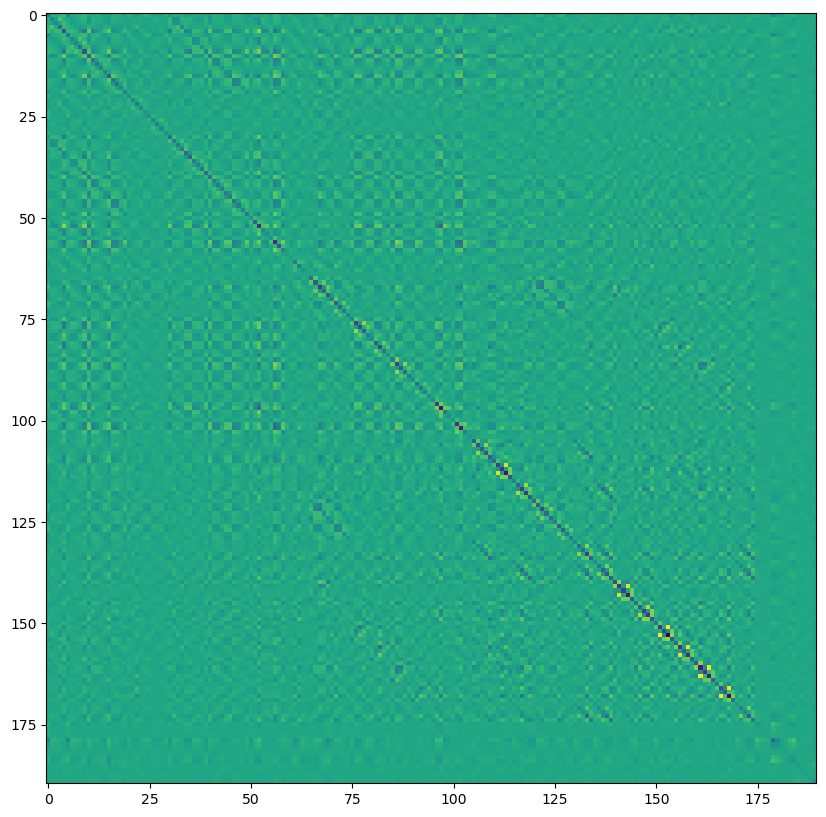

In [135]:
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
im = axs.imshow(finalcov, cmap='viridis_r')

# Prepare covariance matrix input for EFTFitter (almost there)

In [136]:
# Create a ROOT file and TH2F
root_file = ROOT.TFile("covariance_matrix/final_covariance_matrix.root", "RECREATE")
histogram = ROOT.TH2D("covariance_matrix", "Final Covariance Matrix", 
                      len(finalcov[0]), 0, len(finalcov[0]), len(finalcov[1]), 0, len(finalcov[1]))

# Fill the histogram with the matrix values
for i in range(len(finalcov[0])):
    for j in range(np.shape(finalcov)[0]):
        histogram.SetBinContent(i+1, j+1, finalcov[i, j])

# Write the histogram to the ROOT file
histogram.Write()

# Close the ROOT file
root_file.Close()

In [137]:
!ls ./covariance_matrix/ -ltrh

total 17M
-rw-r--r-- 1 he614 4360 121K Feb 25 19:46 statistical_covariance_matrix.root
-rw-r--r-- 1 he614 4360 264K Apr 14 19:33 final_covariance_matrix.root


In [138]:
hepdata_final_cov_matrix['covariance_matrix'].to_hist()

Hist(
  Regular(190, 0, 190, name='xaxis'),
  Regular(190, 0, 190, name='yaxis'),
  storage=Double()) # Sum: 0.006905553324611942

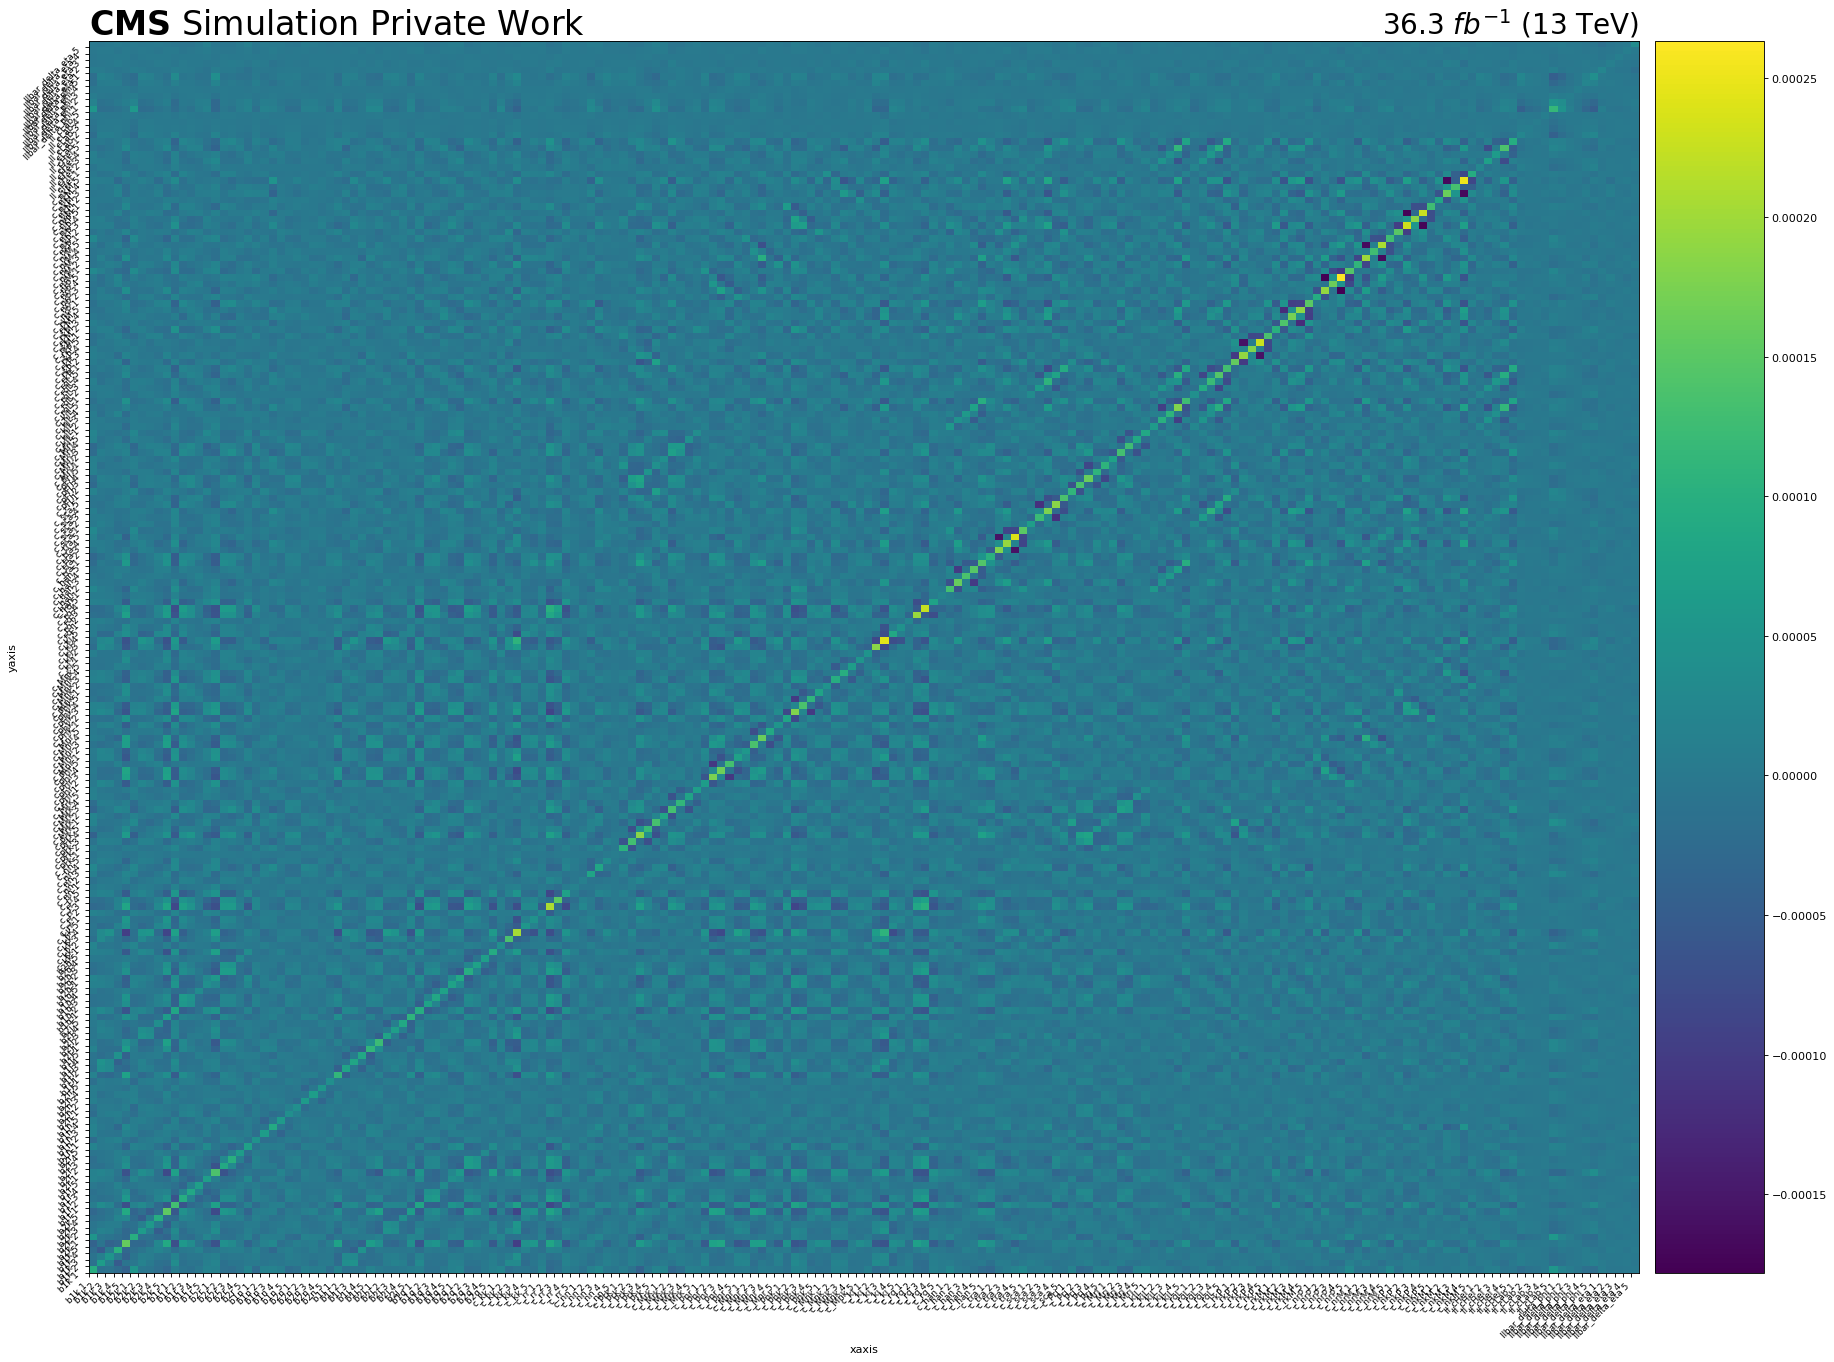

In [176]:
hepdata_final_cov_matrix = uproot.open("covariance_matrix/final_covariance_matrix.root")
hepdata_final_cov_matrix
#finalcov = hepdata_final_cov_matrix['covariance_matrix'].to_hist()

fig, axs = plt.subplots(1, 1, figsize=(25, 20), dpi=80) 
hepdata_final_cov_matrix['covariance_matrix'].to_hist().plot2d()

axs.set_title(r"$\mathbf{CMS}$ Simulation Private Work", fontsize=30, loc="left")
axs.set_title('36.3 $fb^{-1}$ (13 TeV)', fontsize=25, loc="right")

axs.set_yticks(np.arange(len(xy_labels_reduced)))
axs.set_yticklabels(xy_labels_reduced, rotation=45, ha='right', fontsize=8)

axs.set_xticks(np.arange(len(xy_labels_reduced)))
axs.set_xticklabels(xy_labels_reduced, rotation=45, ha='right', fontsize=8)
fig.savefig('finalcov.pdf')

In [179]:
h_concatenated_EFT = {}

op_values = ['0', '2', '-2']

h_concatenated = uproot.open("concatenated_histograms.root")['diff_cross_section'].to_hist()
for value in op_values:
    h_concatenated_EFT[value] = uproot.open(f'concatenated_histograms_ctg{value}.root')['diff_cross_section'].to_hist()


In [180]:
#uproot.open(f'nlo_ctG_root_density/nlo_ctG_{value}_nominal_toppt_default_shape_concatenated.root').keys()

In [181]:
#uproot.open(f'nlo_ctG_root_density/nlo_ctG_{value}_nominal_toppt_default_shape_concatenated.root')['TTbarSpinDensityMatrix;1']['b1q_absolute_part_cut_0;1'].to_hist().plot1d()

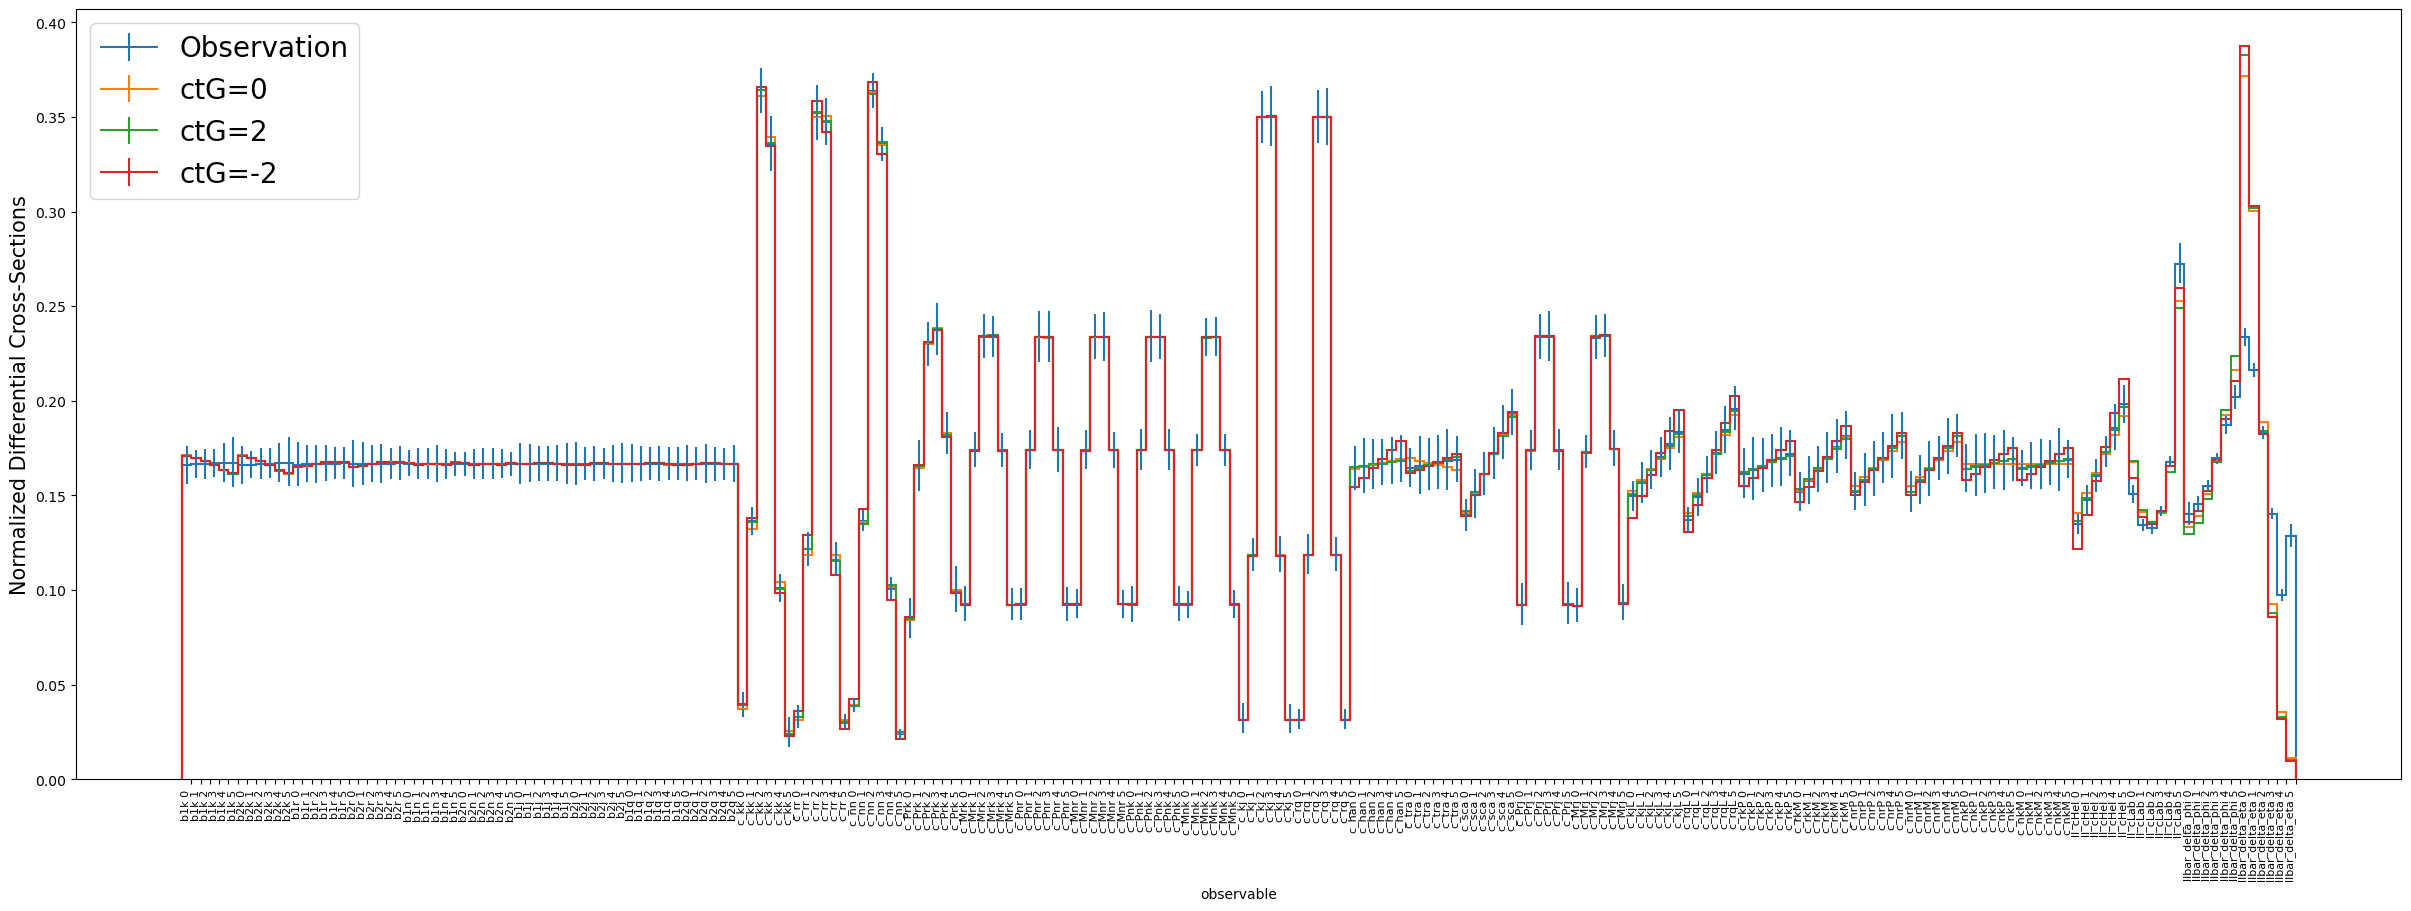

In [184]:
fig, axs = plt.subplots(1, 1, figsize=(30, 10), dpi=100)

h_concatenated.plot1d(label='Observation')
for value in h_concatenated_EFT:
    h_concatenated_EFT[value].plot1d(label=f'ctG={value}')

axs.legend(fontsize=20)
axs.set_ylabel("Normalized Differential Cross-Sections", fontsize=15)
axs.set_xticks(np.arange(len(xy_labels))+1.0)
axs.set_xticklabels(xy_labels, rotation=90, ha='right', fontsize=8)
#axs.tight_layout()  # Automatically adjusts spacing
fig.savefig("concatenated_histograms.pdf", bbox_inches='tight')  # Ensures labels are not cut

# interpolate the values of a quadratic function as a function of op formed by these 3 histograms formed corresponding parameter op_values = ['p0', 'p2', 'm2']

Number of degrees of freedom: 3
Ling: checking cov_inv 
 [[28814.1915357  15512.25523235 11907.16244975 16540.21598469
  13100.41071885]
 [15512.25523235 12297.36197012  7736.67597086 11494.57867324
   9617.7652716 ]
 [11907.16244975  7736.67597086  9540.1405577  10951.64686518
   8998.83542343]
 [16540.21598469 11494.57867324 10951.64686518 20611.18646522
   8522.03198666]
 [13100.41071885  9617.7652716   8998.83542343  8522.03198666
  22642.6288033 ]]
Ling: checking cov_inv 
 [[ 79171.67670974  33306.63640979  24437.46719403  34144.63836705
   50257.99151832]
 [ 33306.63640979  29703.97936264  18295.92746643  35308.80447205
   30651.94971288]
 [ 24437.46719403  18295.92746643  18344.21861324  24999.29411186
   32818.25128644]
 [ 34144.63836705  35308.80447205  24999.29411186  65570.47939154
   33433.20404299]
 [ 50257.99151832  30651.94971288  32818.25128644  33433.20404299
  138435.43468813]]
Ling: checking cov_inv 
 [[11836.58827257 10069.77306888  1781.32414156  8728.86441044
   4

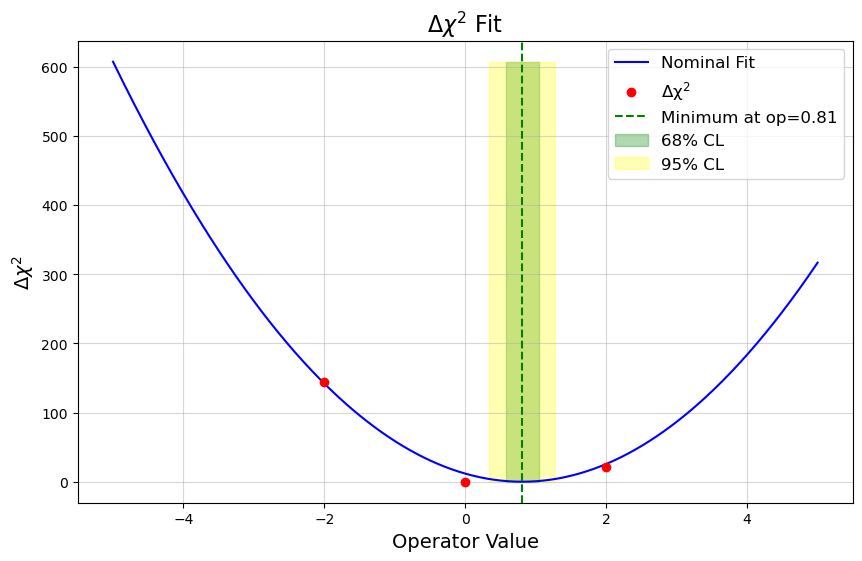

Optimized Fit Parameters: a = 18.017586, op_min = 0.81
Minimum dChi2 occurs at op = 0.81
1-sigma interval width: [0.47]
2-sigma interval width: [0.94]


In [13]:
import numpy as np
import uproot
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_chi2(observable_indices, bins_per_observable, drop_bins, finalcov, op_values, root_file, eft_root_pattern):
    """
    by Lingqiang He 02.13.2025
    
    Parameters:
        observable_indices (list): Indices of the observables to fit.
        bins_per_observable (int): Number of bins per observable.
        drop_bins (list): Indices of bins to drop.
        finalcov (np.array): Full covariance matrix.
        op_values (list): List of operator labels.
        root_file (str): Path to the SM root file.
        eft_root_pattern (str): Pattern for EFT root files.
    """
    chi2_values = []
    ndof = len(observable_indices) - 1
    print("Number of degrees of freedom:", ndof)

    # Load the Standard Model (SM) data
    h_concatenated = uproot.open(root_file)["concatenated_diff_cross_section;1"].to_hist()
    x_obs_full = h_concatenated.values()

    # Identify valid bins (apply drop_bins once at the start)
    valid_bins = np.setdiff1d(np.arange(len(x_obs_full)), drop_bins)
    x_obs_full = x_obs_full[valid_bins]
    
    # Iterate over operator values
    for op in op_values:
        # Load EFT prediction for this operator
        h_concatenated_EFT = uproot.open(eft_root_pattern.format(op=op))["TTbarSpinDensityMatrix;1"]["snake_spinCorr_shape_part_cut_0;1"].to_hist()
        x_hat_full = h_concatenated_EFT.values()
        x_hat_full = x_hat_full[valid_bins]  # Apply the same bin selection
        
        # Ensure dimensions match the covariance matrix
        assert len(x_obs_full) == finalcov.shape[0], f"Observed data mismatch: {len(x_obs_full)} vs {finalcov.shape[0]}"
        assert len(x_hat_full) == finalcov.shape[0], f"EFT prediction mismatch: {len(x_hat_full)} vs {finalcov.shape[0]}"

        total_chi2 = 0  # Accumulate chi² from all observables

        # Compute chi² per observable separately (C++ logic)
        for obs_idx in observable_indices:
            bins = np.arange(obs_idx * bins_per_observable, (obs_idx + 1) * bins_per_observable)
            bins = np.setdiff1d(bins, drop_bins)  # Drop specified bins
            bins = np.searchsorted(valid_bins, bins)  # Adjust indexing to match the reduced set

            if len(bins) == 0:
                continue  # Skip empty sets of bins

            # Extract corresponding submatrix
            cov_submatrix = finalcov[np.ix_(bins, bins)]
            #print("Ling: checking cov_submatrix \n", cov_submatrix)
            cov_inv = np.linalg.inv(cov_submatrix)  # Invert submatrix

            print("Ling: checking cov_inv \n", cov_inv)

            # Compute chi² for this observable
            delta = x_obs_full[bins] - x_hat_full[bins]
            chi2_obs = delta.T @ cov_inv @ delta
            total_chi2 += chi2_obs  # Accumulate chi²

        chi2_values.append(total_chi2)

    # Convert results to NumPy arrays for fitting
    op_numeric = np.array([-2, 0, 2], dtype=float)
    dchi2_values = np.array(chi2_values - np.min(chi2_values))  # Normalize by min(chi²)

    # Define the vertex form of a parabola: chi²(op) = a * (op - op_min)^2
    def parabola_vertex(op, a, op_min):
        return a * (op - op_min) ** 2 

    # Initial guesses: a=1, op_min=0
    p0 = [1, 0]

    # Perform curve fitting
    params, _ = curve_fit(parabola_vertex, op_numeric, dchi2_values, p0=p0)

    # Extract optimized parameters
    a, op_min = params

    # Generate interpolated chi² values
    op_interpolated = np.linspace(-5, 5, 500)
    chi2_interpolated = parabola_vertex(op_interpolated, a, op_min)

    # Compute confidence intervals (1σ and 2σ)
    op_1sigma_shift = np.sqrt(1 / a) if a > 0 else 0
    op_2sigma_shift = np.sqrt(4 / a) if a > 0 else 0

    op_1sigma_min, op_1sigma_max = op_min - op_1sigma_shift, op_min + op_1sigma_shift
    op_2sigma_min, op_2sigma_max = op_min - op_2sigma_shift, op_min + op_2sigma_shift

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(op_interpolated, chi2_interpolated, label="Nominal Fit", color="blue")
    plt.scatter(op_numeric, dchi2_values, color="red", label=r"$\rm \Delta \chi^2$", zorder=5)
    plt.axvline(op_min, color="green", linestyle="--", label=f"Minimum at op={op_min:.2f}")

    # Confidence intervals
    plt.fill_betweenx([0, max(chi2_interpolated)], op_1sigma_min, op_1sigma_max, color="green", alpha=0.3, label="68% CL")
    plt.fill_betweenx([0, max(chi2_interpolated)], op_2sigma_min, op_2sigma_max, color="yellow", alpha=0.3, label="95% CL")

    plt.title("$\Delta \chi^2$ Fit", fontsize=16)
    plt.xlabel("Operator Value", fontsize=14)
    plt.ylabel("$\Delta \chi^2$", fontsize=14)
    #plt.ylim(0, 10)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.5)
    plt.show()

    # Print the results
    print(f"Optimized Fit Parameters: a = {a:.6f}, op_min = {op_min:.2f}")
    print(f"Minimum dChi2 occurs at op = {op_min:.2f}")
    print(f"1-sigma interval width: [{(op_1sigma_max-op_1sigma_min):.2f}]")
    print(f"2-sigma interval width: [{(op_2sigma_max-op_2sigma_min):.2f}]")

# Define parameters
op_values = ["m2", "p0", "p2"]
root_file = "HEPData-concatenated-histogram.root"
eft_root_pattern = "nlo_ctG_root/nlo_ctG_{op}_nominal_toppt_default_shape.root"
observable_indices = np.array([10, 12, 13, 19])  # Select observables to fit
#observable_indices = np.array([1, 2, 3, 4])  # Select observables to fit
#observable_indices = [i for i in range(0, 20)]  # Select observables to fit
bins_per_observable = 6  # Example: each observable has 5 bins
drop_bins = np.arange(1, 132, 6)  # Drop bins as per your rules

# Call the function
#fit_chi2(op_values, root_file, eft_root_pattern, observable_indices, bins_per_observable, drop_bins, finalcov)
fit_chi2(observable_indices, bins_per_observable, drop_bins, finalcov, op_values, root_file, eft_root_pattern)

In [18]:
test_hist = uproot.open('nlo_ctG_root/nlo_ctG_m2_nominal_toppt_default_shape.root')
test_hist['TTbarSpinDensityMatrix/b1j_absolute_part_cut_0;1'].name

'b1j_absolute_part_cut_0'

In [14]:
test_hist['TTbarSpinDensityMatrix/b1j_absolute_part_cut_0;1'].axes[0].edges()[0]

-1.0

In [3]:
# Define input and output directories
input_dir = "nlo_ctG_root/"
output_dir = "nlo_ctG_root_density/"

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Loop through all .root files in the input directory
for root_file in tqdm(os.listdir(input_dir)):
    if root_file.endswith(".root"):
        input_path = os.path.join(input_dir, root_file)
        output_path = os.path.join(output_dir, root_file)
        
        # Open the input .root file for reading
        with uproot.open(input_path) as infile:

            # Write the normalized histograms to a new .root file using ROOT
            root_outfile = ROOT.TFile(output_path, "RECREATE")  
            root_outfile.mkdir('TTbarSpinDensityMatrix')
            root_outfile.cd('TTbarSpinDensityMatrix')            
            for key in infile.keys():
                
                if (key!=infile.keys()[0]):
                    key_hist=key.split('/')[1].replace(';1', '')
        
                    # Normalize the histogram values with uncertainty propagation
                    h_density = normalize_histogram_with_uncertainty(infile[key], input_format="uproot", output_format="ROOT")
        
                    # Write histogram to the file
                    h_density.Write()

            # Close the output file
            root_outfile.Close()

print("Normalization complete with uncertainty propagation. Normalized files saved to:", output_dir)


100%|██████████| 76/76 [00:47<00:00,  1.60it/s]

Normalization complete with uncertainty propagation. Normalized files saved to: nlo_ctG_root_density/


In [4]:
op_values = ['p0', 'p2', 'm2']

for value in op_values:
    # Input and output ROOT file names
    input_file_name = f"nlo_ctG_root_density/nlo_ctG_{value}_nominal_toppt_default_shape.root"
    output_file_name = f"nlo_ctG_root_density/nlo_ctG_{value}_nominal_toppt_default_shape_concatenated.root"
    
    # Open the input ROOT file
    input_file = ROOT.TFile.Open(input_file_name, "READ")
    if not input_file or input_file.IsZombie():
        raise FileNotFoundError(f"Could not open input file {input_file_name}")
    
    # Navigate to the directory
    input_dir = input_file.Get("TTbarSpinDensityMatrix")
    if not input_dir or not isinstance(input_dir, ROOT.TDirectory):
        raise RuntimeError("Directory 'TTbarSpinDensityMatrix' not found in the input file")
    
    # Create output file
    output_file = ROOT.TFile(output_file_name, "RECREATE")
    output_dir = output_file.mkdir("TTbarSpinDensityMatrix")
    output_dir.cd()  # Navigate to the created directory
    
    # Histograms to skip
    skip_histograms = [
        "snake_spinCorr_absolute_part_cut_0",
        "snake_spinHeli_absolute_part_cut_0",
        "snake_spinDens_absolute_part_cut_0",
        "snake_spinColl_absolute_part_cut_0",
        "spin_coeff_absolute_part_cut_0",
        "b1k_shape_part_cut_0",
        "b2k_shape_part_cut_0",
        "b1r_shape_part_cut_0",
        "b2r_shape_part_cut_0",
        "b1n_shape_part_cut_0",
        "b2n_shape_part_cut_0",
        "b1j_shape_part_cut_0",
        "b2j_shape_part_cut_0",
        "b1q_shape_part_cut_0",
        "b2q_shape_part_cut_0",
        "ckk_shape_part_cut_0",
        "crr_shape_part_cut_0",
        "cnn_shape_part_cut_0",
        "cP_rk_shape_part_cut_0",
        "cM_rk_shape_part_cut_0",
        "cP_nr_shape_part_cut_0",
        "cM_nr_shape_part_cut_0",
        "cP_nk_shape_part_cut_0",
        "cM_nk_shape_part_cut_0",
        "cHel_shape_part_cut_0",
        "cLab_shape_part_cut_0",
        "LL_dPhi_shape_part_cut_0",
        "snake_spinCorr_shape_part_cut_0",
        "sumWgt_noCut",
        "sumEvt_noCut"
    ]
    
    # Key to replace with the concatenated histogram
    replace_histogram_key = "snake_spinCorr_absolute_part_cut_0"
    
    # Initialize variables for the concatenated histogram
    concatenated_histogram = None
    bin_offset = 0  # Tracks the bin index offset as we add more histograms
    
    # Collect all keys in the directory
    keys = [key.GetName() for key in input_dir.GetListOfKeys()]
    
    # Calculate total bins for concatenated histogram
    total_bins = 0
    for key in keys:
        if key in skip_histograms:
            continue
        histogram = input_dir.Get(key)
        if isinstance(histogram, ROOT.TH1) and histogram.GetNbinsX() > 0:
            total_bins += histogram.GetNbinsX()
    
    # Create concatenated histogram
    concatenated_histogram = ROOT.TH1D(
        replace_histogram_key,
        "Concatenated Histogram",
        total_bins,
        0,
        total_bins
    )
    
    # Fill concatenated histogram
    for key in keys:
        if key in skip_histograms:
            continue
        histogram = input_dir.Get(key)
        if isinstance(histogram, ROOT.TH1) and histogram.GetNbinsX() > 0:
            for bin in range(1, histogram.GetNbinsX() + 1):
                global_bin = bin + bin_offset
                concatenated_histogram.SetBinContent(global_bin, histogram.GetBinContent(bin))
                concatenated_histogram.SetBinError(global_bin, histogram.GetBinError(bin))
            bin_offset += histogram.GetNbinsX()
    
    # Write all histograms to the output directory
    output_dir.cd()
    for key in keys:
        histogram = input_dir.Get(key)
        if key == replace_histogram_key:
            output_dir.WriteObject(concatenated_histogram, key)
        elif isinstance(histogram, ROOT.TH1):
            histogram.Write()
    
    # Close files
    input_file.Close()
    output_file.Close()
    
    print(f"Concatenated histogram saved to {output_file_name}")


Concatenated histogram saved to nlo_ctG_root_density/nlo_ctG_p0_nominal_toppt_default_shape_concatenated.root
Concatenated histogram saved to nlo_ctG_root_density/nlo_ctG_p2_nominal_toppt_default_shape_concatenated.root
Concatenated histogram saved to nlo_ctG_root_density/nlo_ctG_m2_nominal_toppt_default_shape_concatenated.root


In [5]:
#file_snake_m2_og = uproot.open('nlo_ctG_root/nlo_ctG_m2_nominal_toppt_default_shape.root')
file_snake_p2 = uproot.open('nlo_ctG_root/nlo_ctG_p2_nominal_toppt_default_shape.root')
file_snake_m2 = uproot.open('nlo_ctG_root_density/nlo_ctG_p0_nominal_toppt_default_shape_concatenated.root')

In [6]:
file_snake_m2['TTbarSpinDensityMatrix'].keys()

['normalized;52',
 'normalized;51',
 'normalized;50',
 'normalized;49',
 'normalized;48',
 'normalized;47',
 'normalized;46',
 'normalized;45',
 'normalized;44',
 'normalized;43',
 'normalized;42',
 'normalized;41',
 'normalized;40',
 'normalized;39',
 'normalized;38',
 'normalized;37',
 'normalized;36',
 'normalized;35',
 'normalized;34',
 'normalized;33',
 'normalized;32',
 'normalized;31',
 'normalized;30',
 'normalized;29',
 'normalized;28',
 'normalized;27',
 'normalized;26',
 'normalized;25',
 'normalized;24',
 'normalized;23',
 'normalized;22',
 'normalized;21',
 'normalized;20',
 'normalized;19',
 'normalized;18',
 'normalized;17',
 'normalized;16',
 'normalized;15',
 'normalized;14',
 'normalized;13',
 'normalized;12',
 'normalized;11',
 'normalized;10',
 'normalized;9',
 'normalized;8',
 'normalized;7',
 'normalized;6',
 'normalized;5',
 'normalized;4',
 'normalized;3',
 'normalized;2',
 'normalized;1']

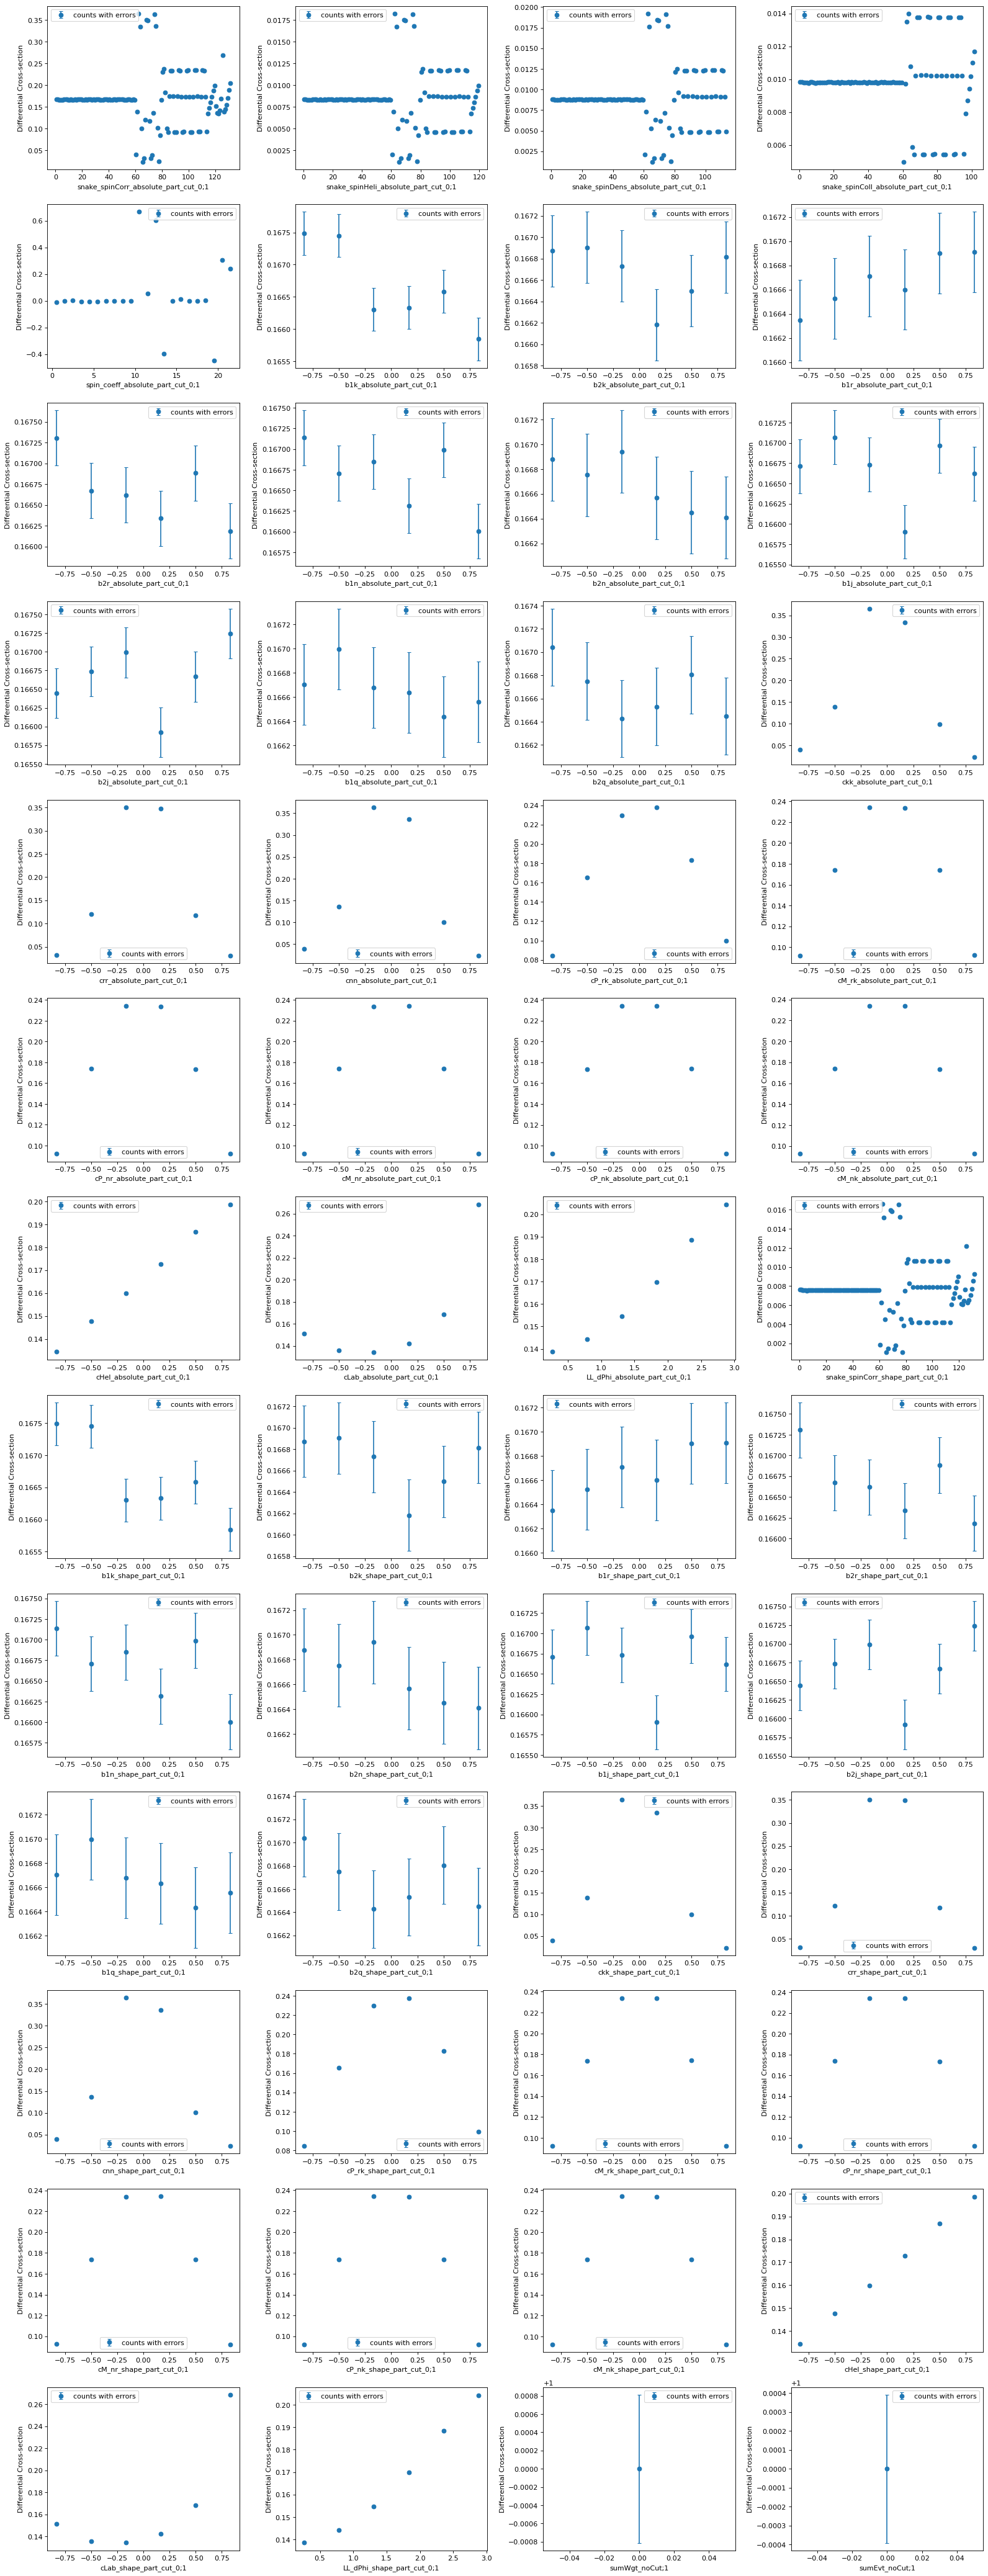

In [268]:
# Determine the number of keys to set up grid size
keys = list(file_snake_m2['TTbarSpinDensityMatrix'].keys())
n_keys = len(keys)

# Set up the subplot grid: Choose rows and columns for better visualization
n_cols = 4  # Adjust this as needed (e.g., 3 columns)
n_rows = (n_keys + n_cols - 1) // n_cols  # Calculate rows needed based on number of columns

# Create a large canvas with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), dpi=80)
axes = axes.flatten()  # Flatten to easily iterate over for 1D indexing

# Loop through each histogram key and plot it on a separate subplot
for i, key in enumerate(keys):
    # Retrieve histogram data
    h_density = file_snake_m2['TTbarSpinDensityMatrix'][key].to_hist()
    values = h_density.values()
    variances = h_density.variances()
    errors = np.sqrt(variances)  # Calculate standard deviation (square root of variance)
    bin_edges = h_density.axes[0].edges  # Get bin edges
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Calculate bin centers for plotting

    # Plot with error bars in the respective subplot
    ax = axes[i]
    ax.errorbar(bin_centers, values, yerr=errors, fmt='o', capsize=3, label='counts with errors')
    ax.set_xlabel(key)
    ax.set_ylabel('Differential Cross-section')
    #ax.set_title(f'Histogram for {key}')
    ax.legend()

# Hide any extra subplots if n_keys is less than n_rows * n_cols
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.savefig('inspect_snake_input.png')

In [174]:
!ls ./example_fit_input/ut_coeff.root -ltrh

-rw-r--r-- 1 he614 4360 14K Feb 23 07:55 ./example_fit_input/ut_coeff.root


In [175]:
check_file = uproot.open('./example_fit_input/ut_coeff.root')

In [176]:
check_file.keys()

['sm_nominal;1',
 'sm_up;1',
 'sm_down;1',
 'ut_nominal;1',
 'ut_up;1',
 'ut_down;1',
 'sm_nominal_plus_ut_nominal;1',
 'sm_nominal_plus_ut_up;1',
 'sm_nominal_plus_ut_down;1',
 'sm_up_plus_ut_nominal;1',
 'sm_up_plus_ut_up;1',
 'sm_up_plus_ut_down;1',
 'sm_down_plus_ut_nominal;1',
 'sm_down_plus_ut_up;1',
 'sm_down_plus_ut_down;1',
 'sm_nominal_minus_ut_nominal;1',
 'sm_nominal_minus_ut_up;1',
 'sm_nominal_minus_ut_down;1',
 'sm_up_minus_ut_nominal;1',
 'sm_up_minus_ut_up;1',
 'sm_up_minus_ut_down;1',
 'sm_down_minus_ut_nominal;1',
 'sm_down_minus_ut_up;1',
 'sm_down_minus_ut_down;1']

/tmp/ipykernel_1429/5456901.py:48: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 4)


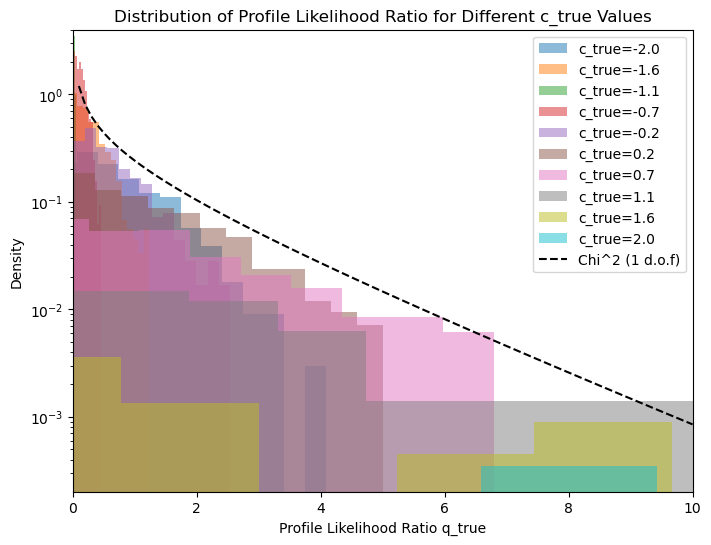

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, multivariate_normal

# Define the quadratic parameterization for the cross-section function

def mu(c, s=1, la=1, t_ab=0.5, n=0.2):
    return s + la * c + t_ab * c ** 2 + n  # Simple quadratic model

# Generate synthetic observed data x
np.random.seed(42)
c_true_values = np.linspace(-2, 2, 10)  # Different values of true c
num_samples = 1000  # Number of pseudo-experiments
cov_matrix = np.array([[0.5]])  # Covariance matrix (assumed scalar for simplicity)

q_values = []  # Store test statistics for each c_true

for c_true in c_true_values:
    x_samples = np.random.normal(mu(c_true), np.sqrt(cov_matrix[0, 0]), num_samples)
    
    q_x_c = []
    for x in x_samples:
        # Compute chi-squared statistic
        chi2_x_c = (x - mu(c_true)) ** 2 / cov_matrix[0, 0]
        # Compute profile likelihood ratio
        la = 1  # Define la explicitly
        t_ab = 0.5  # Define t_ab explicitly
        c_min = -la / (2 * t_ab)  # MLE for c
        chi2_min = (x - mu(c_min)) ** 2 / cov_matrix[0, 0]
        q = chi2_x_c - chi2_min
        q_x_c.append(q)
    
    q_values.append(q_x_c)

# Plot the distribution of q_true for different c_true
plt.figure(figsize=(8, 6))
for i, c_true in enumerate(c_true_values):
    plt.hist(q_values[i], bins=30, density=True, alpha=0.5, label=f"c_true={c_true:.1f}")
    
# Overlay the chi-squared distribution (Wilks' theorem assumption)
x_vals = np.linspace(0, 10, 100)
plt.plot(x_vals, chi2.pdf(x_vals, df=1), 'k--', label='Chi^2 (1 d.o.f)')

plt.xlabel("Profile Likelihood Ratio q_true")
plt.ylabel("Density")
plt.yscale('log')
plt.xlim(0, 10)
plt.ylim(0, 4)
plt.title("Distribution of Profile Likelihood Ratio for Different c_true Values")
plt.legend()
plt.show()